In [1]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.shape

(7043, 21)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [5]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [8]:
df = df.dropna()

In [9]:
df.shape

(7032, 21)

In [10]:
df["Churn"].value_counts()

,count
Churn,
No,5163
Yes,1869


In [11]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.421502
Yes,26.578498


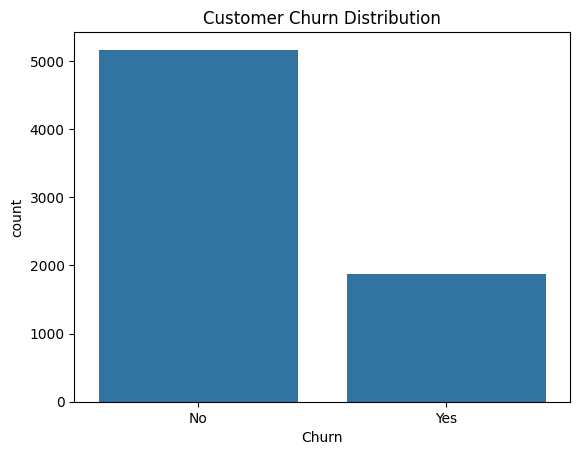

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")

plt.show()

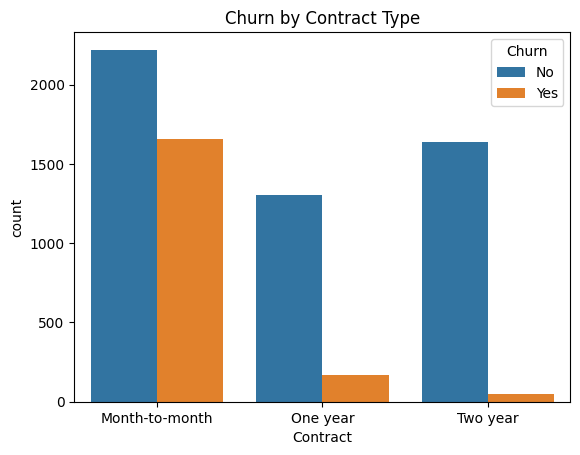

In [13]:
sns.countplot(x="Contract", hue="Churn", data=df)

plt.title("Churn by Contract Type")

plt.show()

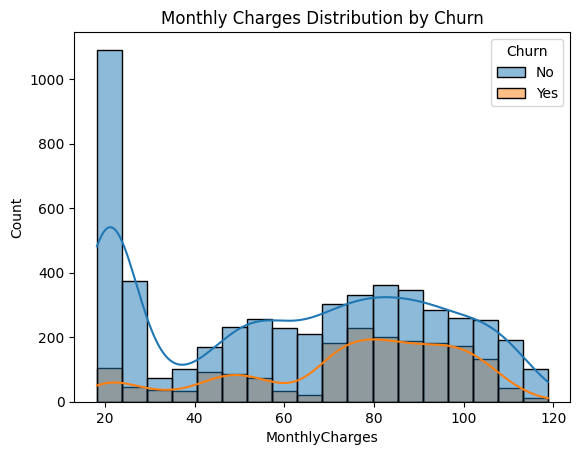

In [14]:
sns.histplot(data=df, x="MonthlyCharges", hue="Churn", kde=True)

plt.title("Monthly Charges Distribution by Churn")

plt.show()

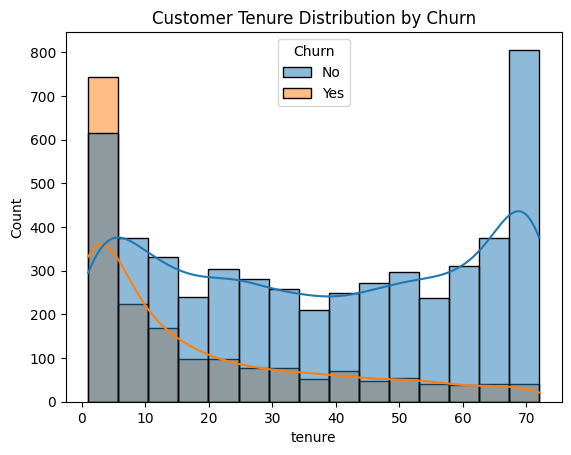

In [15]:
sns.histplot(data=df, x="tenure", hue="Churn", kde=True)

plt.title("Customer Tenure Distribution by Churn")

plt.show()

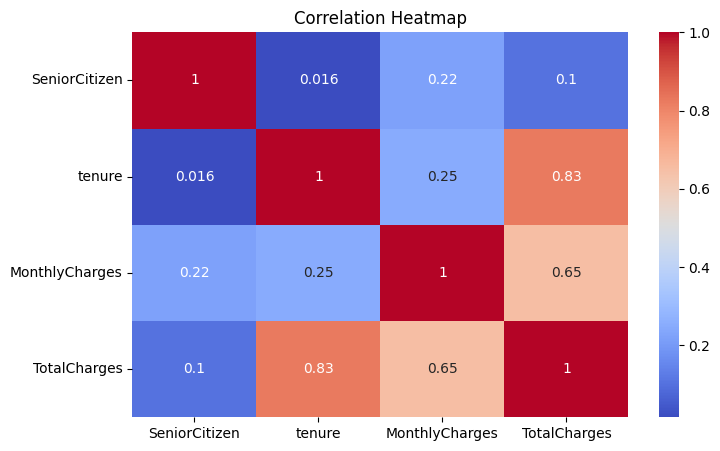

In [16]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

corr = numeric_df.corr()

plt.figure(figsize=(8,5))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

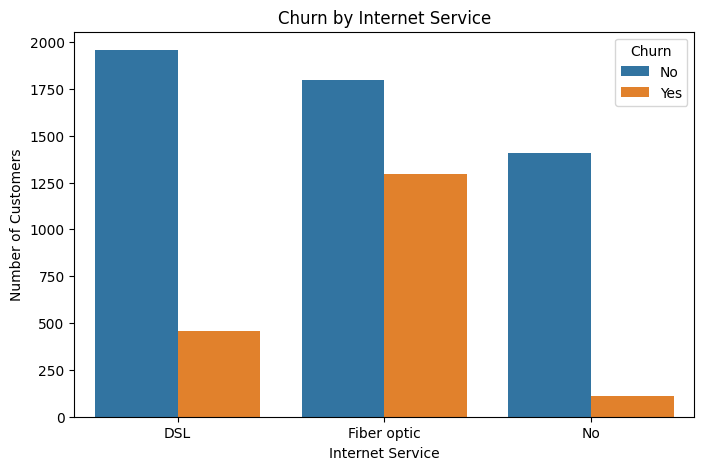

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(x="InternetService", hue="Churn", data=df)

plt.title("Churn by Internet Service")

plt.xlabel("Internet Service")

plt.ylabel("Number of Customers")

plt.show()

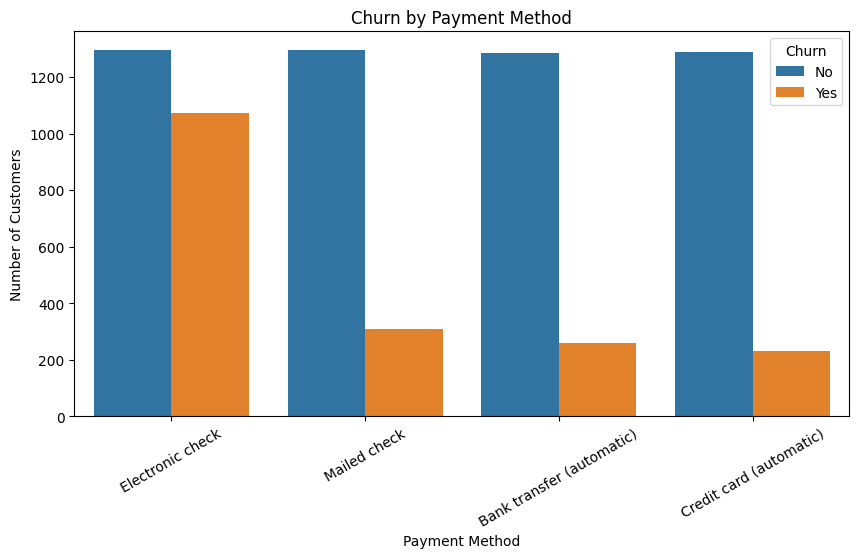

In [18]:
plt.figure(figsize=(10,5))

sns.countplot(x="PaymentMethod", hue="Churn", data=df)

plt.title("Churn by Payment Method")

plt.xticks(rotation=30)

plt.xlabel("Payment Method")

plt.ylabel("Number of Customers")

plt.show()

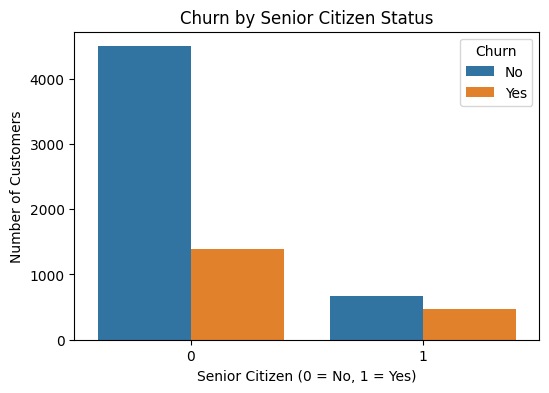

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(x="SeniorCitizen", hue="Churn", data=df)

plt.title("Churn by Senior Citizen Status")

plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")

plt.ylabel("Number of Customers")

plt.show()

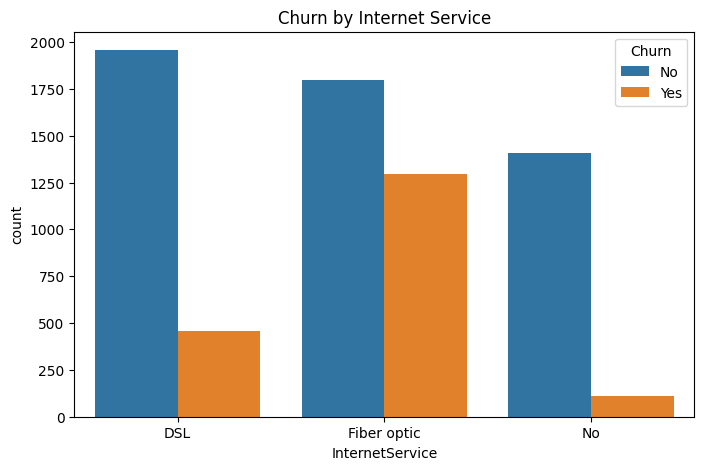

In [20]:
plt.figure(figsize=(8,5))

sns.countplot(x="InternetService", hue="Churn", data=df)

plt.title("Churn by Internet Service")

plt.show()

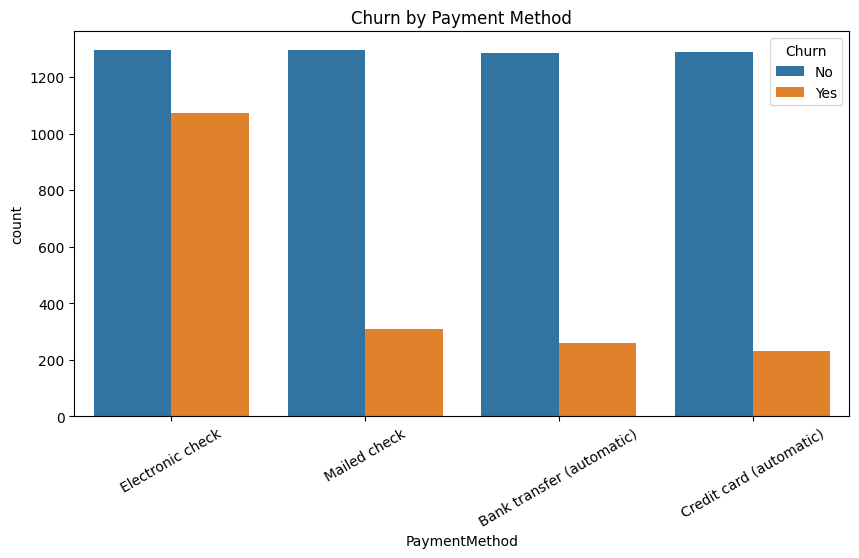

In [21]:
plt.figure(figsize=(10,5))

sns.countplot(x="PaymentMethod", hue="Churn", data=df)

plt.title("Churn by Payment Method")

plt.xticks(rotation=30)

plt.show()

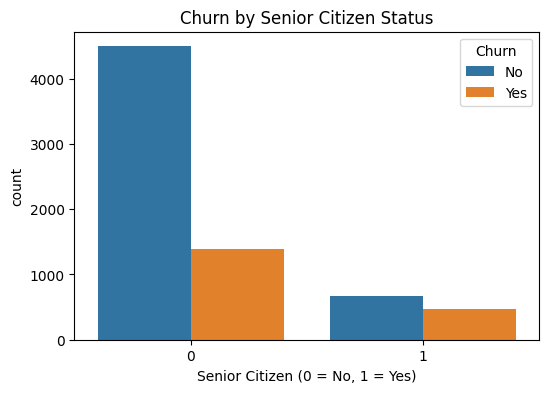

In [22]:
plt.figure(figsize=(6,4))

sns.countplot(x="SeniorCitizen", hue="Churn", data=df)

plt.title("Churn by Senior Citizen Status")

plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")

plt.show()

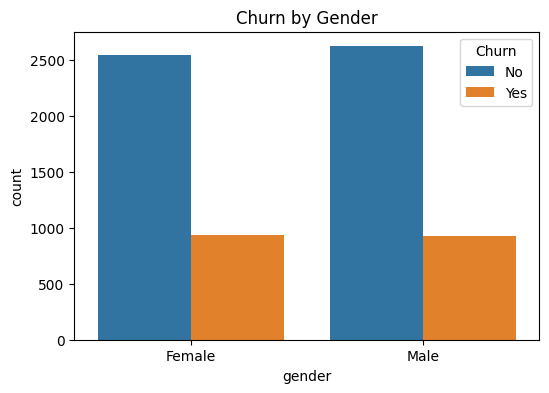

In [23]:
plt.figure(figsize=(6,4))

sns.countplot(x="gender", hue="Churn", data=df)

plt.title("Churn by Gender")

plt.show()

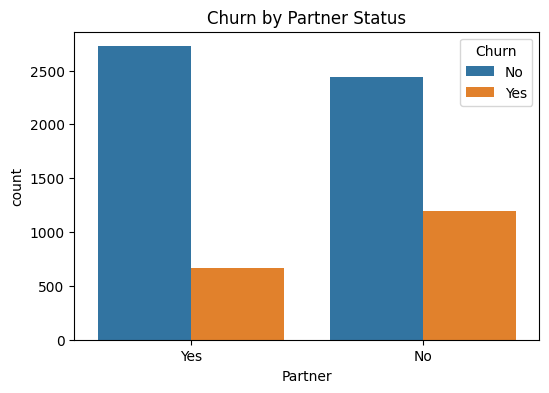

In [24]:
plt.figure(figsize=(6,4))

sns.countplot(x="Partner", hue="Churn", data=df)

plt.title("Churn by Partner Status")

plt.show()

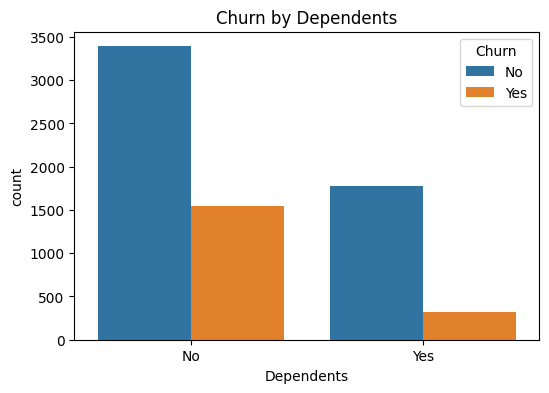

In [25]:
plt.figure(figsize=(6,4))

sns.countplot(x="Dependents", hue="Churn", data=df)

plt.title("Churn by Dependents")

plt.show()

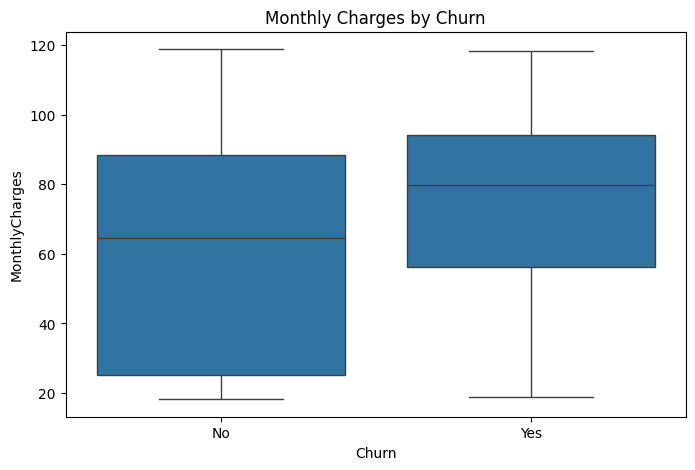

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Churn", y="MonthlyCharges", data=df)

plt.title("Monthly Charges by Churn")

plt.show()

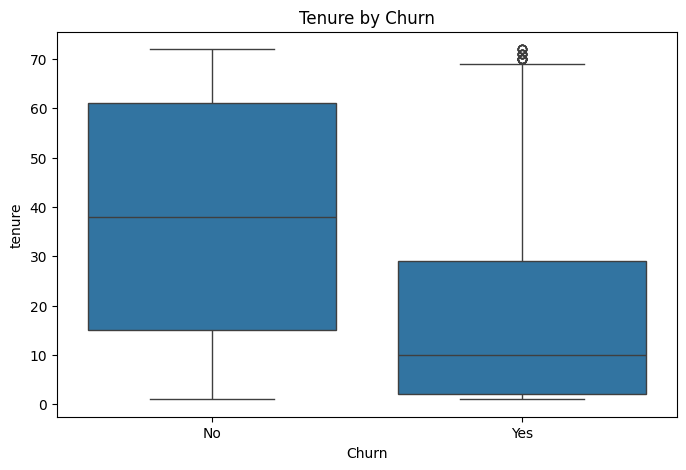

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Churn", y="tenure", data=df)

plt.title("Tenure by Churn")

plt.show()

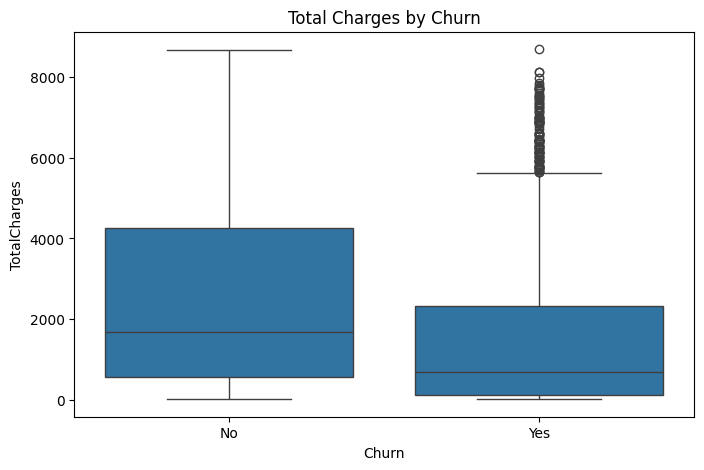

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Churn", y="TotalCharges", data=df)

plt.title("Total Charges by Churn")

plt.show()

In [29]:
# Detect outliers using the IQR method

numerical_columns = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"\n{col}")
    print(f"Lower Bound: {lower:.2f}")
    print(f"Upper Bound: {upper:.2f}")
    print(f"Number of Outliers: {len(outliers)}")


tenure
Lower Bound: -60.00
Upper Bound: 124.00
Number of Outliers: 0

MonthlyCharges
Lower Bound: -45.82
Upper Bound: 171.27
Number of Outliers: 0

TotalCharges
Lower Bound: -4688.48
Upper Bound: 8884.67
Number of Outliers: 0


In [30]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [31]:
df.nunique()

,0
customerID,7032
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,72
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3


In [32]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [33]:
# ==========================================================
# Define the Target Variable
# This variable represents the prediction target for the
# machine learning model.
# ==========================================================

target = "Churn"

print("Target Variable:", target)

Target Variable: Churn


In [34]:
# ==========================================================
# Identify Numerical and Categorical Features
# Separate the dataset into numerical and categorical
# variables for preprocessing.
# ==========================================================

numerical_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Features:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [35]:
# ==========================================================
# Remove the Target Variable from Input Features
# Churn is the prediction target and should not be
# included as an input feature.
# ==========================================================

categorical_features.remove("Churn")

print(categorical_features)

['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [36]:
# ==========================================================
# Remove Customer ID
# customerID is only an identifier and does not contribute
# to predicting customer churn.
# ==========================================================

categorical_features.remove("customerID")

print(categorical_features)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [37]:
# ==========================================================
# Final Feature Summary
# Display the number of numerical features, categorical
# features, and confirm the target variable.
# ==========================================================

print("Number of Numerical Features:", len(numerical_features))
print("Number of Categorical Features:", len(categorical_features))
print("Target Variable:", target)

print("\nNumerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Number of Numerical Features: 4
Number of Categorical Features: 15
Target Variable: Churn

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
